## UNet Architecture

## Key Model Components

My UNet uses several important techniques for effective underwater image segmentation. 

**Attention blocks** are placed between the encoder and decoder stages to help the model focus on the right spatial features. This makes segmentation more accurate by ignoring irrelevant background information and concentrating only on object edges. 

**MaxPooling layers** shrink the feature maps in the encoder, reducing their size while keeping the important features. This helps the network understand the bigger picture more efficiently. 

**ReLU activation functions** add non-linearity throughout the network, letting it learn the complex patterns in underwater images while avoiding training problems where gradients become too small. 

### Building Blocks
Each `ConvBlock` consists of:
- Conv2d -> BatchNorm -> ReLU
- Conv2d -> BatchNorm -> ReLU

Each `AttentionBlock` consists of:
- W_g: Conv2d + BatchNorm -> 2 layers
- W_x: Conv2d + BatchNorm -> 2 layers  
- psi: Conv2d + BatchNorm + Sigmoid -> 3 layers
- ReLU -> 1 layer

### Encoder Section
| Layer | Description            | Layer Count |
|-------|------------------------|-------------|
| enc1  | ConvBlock(3 -> 64)     | 6           |
| pool1 | MaxPool2d              | 1           |
| enc2  | ConvBlock(64 -> 128)   | 6           |
| pool2 | MaxPool2d              | 1           |
| enc3  | ConvBlock(128 -> 256)  | 6           |
| pool3 | MaxPool2d              | 1           |
| enc4  | ConvBlock(256 -> 512)  | 6           |
| pool4 | MaxPool2d              | 1           |
| enc5  | ConvBlock(512 -> 1024) | 6           |

**Total Encoder Layers: 34**

### Bottleneck Section
The bottleneck is `enc5` in the encoder section.

### Attention Section
| Layer | Description                   | Layer Count |
|-------|-------------------------------|-------------|
| att6  | AttentionBlock(512,512,256)   | 8           |
| att7  | AttentionBlock(256,256,128)   | 8           |
| att8  | AttentionBlock(128,128,64)    | 8           |
| att9  | AttentionBlock(64,64,32)      | 8           |

**Total Attention Layers: 32**

### Decoder Section
Each decoder stage combines:
- ConvTranspose2d (1 layer)
- ConvBlock (6 layers)

| Layer | Description                   | Layer Count |
|-------|-------------------------------|-------------|
| up6   | ConvTranspose2d(1024 -> 512)  | 1           |
| dec6  | ConvBlock(1024 -> 512)        | 6           |
| up7   | ConvTranspose2d(512 -> 256)   | 1           |
| dec7  | ConvBlock(512 -> 256)         | 6           |
| up8   | ConvTranspose2d(256 -> 128)   | 1           |
| dec8  | ConvBlock(256 -> 128)         | 6           |
| up9   | ConvTranspose2d(128 -> 64)    | 1           |
| dec9  | ConvBlock(128 -> 64)          | 6           |

**Total Decoder Layers: 28**

### Output Layer
Final convolution layer for segmentation output: **1 layer**

### Architecture Summary
| Section   | Layer Count |
|-----------|-------------|
| Encoder   | 34          |
| Attention | 32          |
| Decoder   | 28          |
| Output    | 1           |
| **Total** | **95**      |

In [1]:
import os
from os.path import join, exists
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:32"

import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import numpy as np
import matplotlib.pyplot as plt

from models.unet import UNet

import random
from tqdm import tqdm

## Class Labels and Evaluation Metrics

### RGB to Class Index

The SUIM dataset has 8 classes. Each class is represented by a unique RGB color in the mask images. Since deep learning models can only process numerical data (class indices), we must convert these RGB masks into integer-labeled masks. This is done using the `rgb_to_class()` function.

The color map to class indices table is below:

| Object Type        | Mask Color Name    | Class Index |
|--------------------|--------------------|--------------|
| Background         | Black              | 0            |
| Human Diver        | Blue               | 1            |
| Aquatic Plants     | Lime Green         | 2            |
| Wrecks and Ruins   | Cyan               | 3            |
| Robots             | Red                | 4            |
| Reefs              | Magenta            | 5            |
| Fish               | Yellow             | 6            |
| Sea Floor          | White              | 7            |


The `rgb_to_class()` function loops through the pixels in the RGB mask and replaces each RGB value with a corresponding class index. This makes a 2D mask of shape (H, W) that contains a pixel value from 0 to 7.

This step is necessary because the model outputs a probability of the pixel belonging to a class. In order to compare the predicted mask to the ground truth mask we need to compare the class indices.

---

### Evaluation Metrics

#### Pixel Accuracy

Pixel accuracy measures the percentage of pixels in the predicted mask that match the ground truth mask.

Formula: `pixel_accuracy = (number of correct pixels) / (total number of pixels)`

Higher values indicate better segmentation performance. 0 is the minimium value and 1 is the highest value.

---

#### Dice Coefficient

The Dice coefficient measures the overlap between the predicted mask pixels and the ground truth mask pixels. It is especially important to analyze in this project because of the class imbalance in the SUIM dataset.

Formula for each class: `Dice = (2 * intersection + smooth) / (prediction sum + label sum + smooth)`

Where:
- intersection = number of overlapping pixels between prediction and ground truth
- smooth = small constant to prevent division by zero

1 represents perfect overlap and very small values (1e-8) represent little to no overlap.

---

#### Intersection over Union (IoU)

IoU, also measures overlap between the predicted mask and the ground truth mask.

Formula: `IoU = (intersection + smooth) / (union + smooth)`

Where:
- intersection = number of overlapping pixels between prediction and ground truth
- union = total number of pixels predicted as the class OR labeled as the class
- smooth = small constant to prevent division by zero

The IoU score also ranges from (1e-8) to 1, where higher values indicate better overlap.

---

#### Cross Entropy Loss

Cross entropy loss is used as the training criterion. For 8-class classification, the model outputs 8 scores per pixel. These scores are called logits and are the likelyhood of the pixel belonging to a particular class. In the code `nn.CrossEntropyLoss` compares the logits with the target class index.

It applies the softmax function and computes: `Loss = -log(predicted probability of true class)`

- A lower loss means the model is more correct in its prediction.
- A random guess using 8 classes results in loss around log(8) ≈ 2.08.

When watching the epochs process you will see a loss value:
- Loss > 2.08 represents inacurate predictions
- Loss < 0.5 represents good quality predictions

---



In [2]:
COLOR2CLASS = {
    (0, 0, 0): 0, # Background
    (0, 0, 255): 1, # Human Diver
    (0, 255, 0): 2, # Aquatic Plants
    (0, 255, 255): 3, # Wrecks and Ruins
    (255, 0, 0): 4, # Robots
    (255, 0, 255): 5, # Reefs
    (255, 255, 0): 6, # Fish
    (255, 255, 255): 7 # Sea floor
}

def rgb_to_class(mask_rgb):
    h, w, _ = mask_rgb.shape
    class_mask = np.zeros((h, w), dtype=np.uint8)
    
    for color, class_idx in COLOR2CLASS.items():
        matches = np.all(mask_rgb == color, axis=-1)
        class_mask[matches] = class_idx
    
    return class_mask

def pixel_accuracy(preds, labels):
    preds = torch.argmax(preds, dim=1)
    correct = (preds == labels).float()
    return correct.sum() / correct.numel()

def calculate_dice_coefficient(preds, labels, num_classes=8, smooth=1e-8):
    #Dice = 2 * (P * R) / (P + R)
    preds = torch.argmax(preds, dim=1)
    dice_scores = []
    
    for class_idx in range(num_classes):
        pred_class = (preds == class_idx).float()
        true_class = (labels == class_idx).float()
        
        intersection = (pred_class * true_class).sum()
        union = pred_class.sum() + true_class.sum()
        
        if union == 0:
            dice = 1.0 if intersection == 0 else 0.0
            dice_scores.append(dice)  # Append the float directly
        else:
            dice = (2.0 * intersection + smooth) / (union + smooth)
            dice_scores.append(dice.item())
    
    return dice_scores

def calculate_iou(preds, labels, num_classes=8, smooth=1e-8):
    preds = torch.argmax(preds, dim=1)
    iou_scores = []
    
    for class_idx in range(num_classes):
        pred_class = (preds == class_idx).float()
        true_class = (labels == class_idx).float()
        
        intersection = (pred_class * true_class).sum()
        union = pred_class.sum() + true_class.sum() - intersection
        
        if union == 0:
            iou = 1.0 if intersection == 0 else 0.0
            iou_scores.append(iou)
        else:
            iou = (intersection + smooth) / (union + smooth)
            iou_scores.append(iou.item())
    
    return iou_scores

def plot_training_metrics(epoch_losses, epoch_accuracies, epoch_dice_scores, epoch_iou_scores):
    epochs = range(1, len(epoch_losses) + 1)
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot Loss
    ax1.plot(epochs, epoch_losses, 'b-', linewidth=2, label='Training Loss')
    ax1.set_title('Training Loss Over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Plot Pixel Accuracy
    ax2.plot(epochs, epoch_accuracies, 'g-', linewidth=2, label='Pixel Accuracy')
    ax2.set_title('Pixel Accuracy Over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # Plot Mean Dice Score
    ax3.plot(epochs, epoch_dice_scores, 'r-', linewidth=2, label='Mean Dice Score')
    ax3.set_title('Mean Dice Coefficient Over Epochs')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Dice Score')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # Plot Mean IoU Score
    ax4.plot(epochs, epoch_iou_scores, 'm-', linewidth=2, label='Mean IoU Score')
    ax4.set_title('Mean IoU Over Epochs')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('IoU Score')
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    
    plt.tight_layout()
    plt.show()

## SUIMDataset

The dataset class allows us to load images and masks without physically modifying the original file organization. Instead of manually splitting the dataset into folders, it accepts a `root_dir` path as well as the subfolders containing our information we will process:

- `image_folder`: Subdirectory with RGB underwater images
- `mask_folder`: Subdirectory with RGB segmentation masks

### Class Parameters

- `root_dir`: Root directory containing the image and mask subfolders (./SUIM)
- `image_folder`: Folder name for RGB images (./SUIM/train_val/images)
- `mask_folder`: Folder name for RGB masks (./SUIM/train_val/masks)
- `target_size`: Tuple (width, height) with the ideal image size for model processing
- `augment`: If `True`, applies data augmentation

### Preprocessing Transforms, and Data Normalization

These are the dataset's preprocessing steps:

1. Images and masks are read using OpenCV and are converted from BGR to RGB

2. Images and masks are resized to the specified size

3. If the augment is true horizontal flipping will be randomly applied. When probability is 50%, images and masks are horizontally flipped. This creates randomization in the dataset leading to effective training data

4. Images are scaled to the [0, 1] range using `astype(np.float32) / 255.`
   - Images are the transposed from (H, W, C) to (C, H, W) for compatibility with pytorch functions
   - Masks are converted from RGB colors to class indices

### Output Format

Each item returned by the dataset is a tuple of the form (image_tensor, class_mask_tensor)


In [6]:
class SUIMDataset(Dataset):
    def __init__(self, root_dir, image_folder="images", mask_folder="masks", target_size=(320, 240), augment=False):
        self.image_dir = join(root_dir, image_folder)
        self.mask_dir = join(root_dir, mask_folder)
        self.images = sorted(os.listdir(self.image_dir))
        self.masks = sorted(os.listdir(self.mask_dir))
        self.target_size = target_size
        self.augment = augment

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(self.target_size),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = join(self.image_dir, self.images[idx])
        mask_path = join(self.mask_dir, self.masks[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

        image = cv2.resize(image, self.target_size)
        mask = cv2.resize(mask, self.target_size)

        if self.augment and random.random() > 0.5:
            image = np.fliplr(image).copy()
            mask = np.fliplr(mask).copy()

        image = image.astype(np.float32) / 255.
        #mask = mask.astype(np.float32) / 255.

        image = np.transpose(image, (2, 0, 1))
        #mask = np.transpose(mask, (2, 0, 1))
        class_mask = rgb_to_class(mask)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(class_mask, dtype=torch.long)


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(input_channels=3, num_classes=8).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training Loop

## Configuration Parameters
- **Dataset**: SUIM Dataset mentioned above with pre-applied transformations
- **Input Size**: 320×240 pixels with data augmentation
- **Batch Size**: 4 samples per batch
- **Training Duration**: 120 epochs
- **Data Loading**: 2 worker processes with shuffling enabled
- **Model Checkpoint**: `ckpt/unet_rgb.pth`

## Training Process

### Initialization
The training loop begins by loading the previous best model weights if available. Then it initializes variables for tracking the modt ideal losses, accuracies, Dice coefficients, and IoU scores across every epoch.

### Epoch Training
Each epoch processes the entire training dataset in batches of size 4. For every batch, the model performs forward propagation to make mask predictions. Then it computes the loss using the cross entropy criterion. Finally it updates weights via backpropagation with the optimizer.

### Metric Calculations
The loop calculates the four metrics mentioned above using their respective calculation functions. Cross entropy loss is used as the parameter that determines the best possible weights.

### Checkpoint
The training loop takes the best average loss and compares it with the current average loss. If the current loss is better, the weights will be saved in the ckpt directory and used in the following epochs as the best model.

### Performance Monitoring & Visualization
Throughout training, epoch-level averages for all metrics are calculated and stored in arrays. After completing all 120 epochs, the `plot_training_metrics()` function generates graphs showing the improvement in metric over time. These plots give us validation that the model is successfully learning with improving accuracy as the training progresses.

Loading checkpoint from ckpt/unet_rgb.pth


Epoch 1/15: 100%|██████| 382/382 [02:23<00:00,  2.67it/s, acc=0.898, loss=0.313]


Epoch 1 - Loss: 0.3127 - Pixel Accuracy: 89.84%
Saved best model checkpoint at epoch 1


Epoch 2/15: 100%|██████| 382/382 [02:25<00:00,  2.63it/s, acc=0.896, loss=0.322]


Epoch 2 - Loss: 0.3219 - Pixel Accuracy: 89.56%


...

Epoch 13 - Loss: 0.2499 - Pixel Accuracy: 92.02%
Saved best model checkpoint at epoch 13


Epoch 14/15: 100%|██████| 382/382 [02:28<00:00,  2.57it/s, acc=0.92, loss=0.246]


Epoch 14 - Loss: 0.2465 - Pixel Accuracy: 91.98%
Saved best model checkpoint at epoch 14


Epoch 15/15: 100%|█████| 382/382 [02:28<00:00,  2.57it/s, acc=0.915, loss=0.261]


Epoch 15 - Loss: 0.2605 - Pixel Accuracy: 91.53%


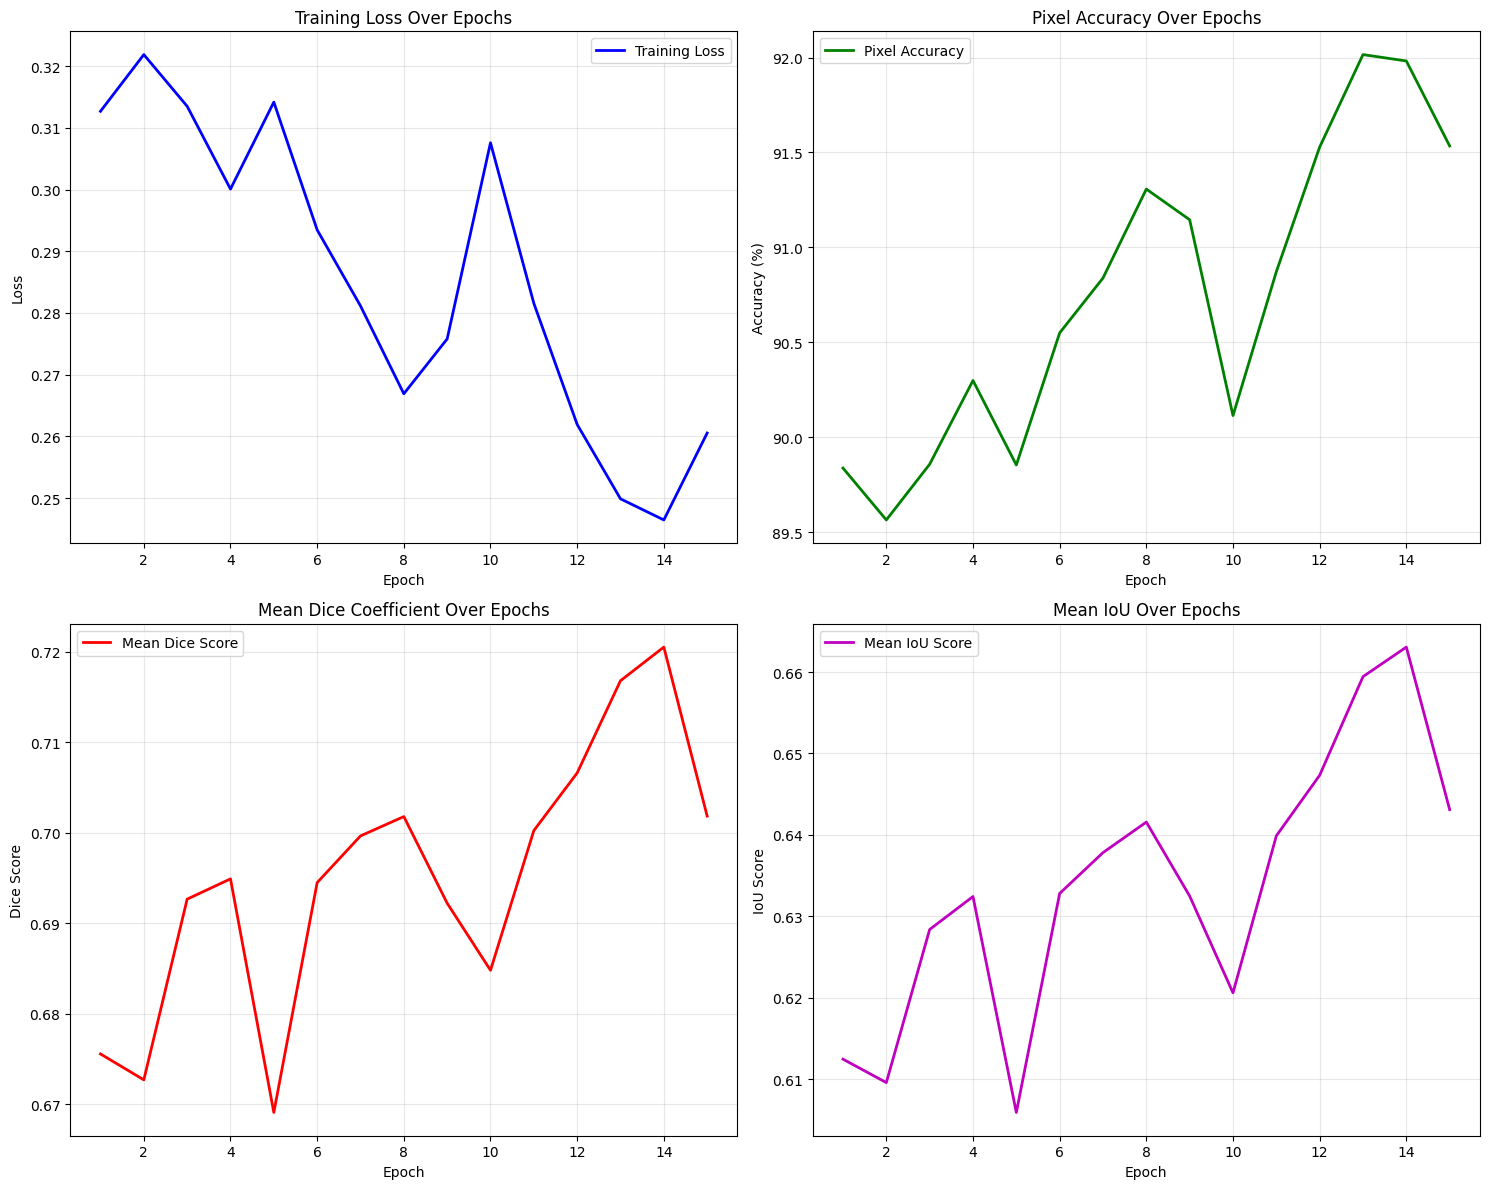

In [5]:
train_dir = "./SUIM/train_val"
batch_size = 4
num_epochs = 120

train_dataset = SUIMDataset(root_dir=train_dir, target_size=(320, 240), augment=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

ckpt_dir = "ckpt/"
ckpt_name = "unet_rgb.pth"
model_ckpt_path = join(ckpt_dir, ckpt_name)
if not exists(ckpt_dir):
    os.makedirs(ckpt_dir)

if os.path.exists(model_ckpt_path):
    print(f"Loading checkpoint from {model_ckpt_path}")
    model.load_state_dict(torch.load(model_ckpt_path, map_location=device))

best_loss = float('inf')  # Initialize best loss to very high

e_losses = []
e_accuracies = []
e_dice = []
e_iou = []

# Training loop
for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    running_dice = [0.0] * 8
    running_iou = [0.0] * 8
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}")

    for i, (images, masks) in enumerate(pbar, 1):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)  # (B, C, H, W)

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        #just added
        acc = pixel_accuracy(outputs, masks)
        dice_scores = calculate_dice_coefficient(outputs, masks)
        iou_scores = calculate_iou(outputs, masks)
        
        running_acc += acc.item()
        running_loss += loss.item()

        for j in range(8):
            running_dice[j] += dice_scores[j]
            running_iou[j] += iou_scores[j]
        
        pbar.set_postfix(loss=running_loss / i, acc=running_acc / i)

    avg_loss = running_loss / len(train_loader)
    avg_acc = running_acc / len(train_loader)
    avg_dice = [score / len(train_loader) for score in running_dice]
    avg_iou = [score / len(train_loader) for score in running_iou]
    
    mean_dice = np.mean(avg_dice)
    mean_iou = np.mean(avg_iou)

    e_losses.append(avg_loss)
    e_accuracies.append(avg_acc * 100)
    e_dice.append(mean_dice)
    e_iou.append(mean_iou)
    
    print(f"Epoch {epoch} - Loss: {avg_loss:.4f} - Pixel Accuracy: {avg_acc*100:.2f}%")

    # Save checkpoint only if the loss improved
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), model_ckpt_path)
        print(f"Saved best model checkpoint at epoch {epoch}")
        
plot_training_metrics(e_losses, e_accuracies, e_dice, e_iou)